In [11]:
# Step 1: Load and Flatten the JSON Data

import json
import pandas as pd
import numpy as np

# Open and parse the JSON file
with open('tarot-images.json', 'r', encoding='utf-8') as f:
    tarot_data = json.load(f)

# Flatten nested JSON data safely into a standard DataFrame
if 'cards' in tarot_data:
    df_tarot = pd.json_normalize(tarot_data['cards'])
else:
    df_tarot = pd.json_normalize(tarot_data)

print(f"Dataset successfully loaded! Total rows: {df_tarot.shape[0]}, Total columns: {df_tarot.shape[1]}")
print(f"\nColumns found in your dataset:\n{df_tarot.columns.tolist()}")

Dataset successfully loaded! Total rows: 78, Total columns: 17

Columns found in your dataset:
['name', 'number', 'arcana', 'suit', 'img', 'fortune_telling', 'keywords', 'Archetype', 'Hebrew Alphabet', 'Numerology', 'Elemental', 'Mythical/Spiritual', 'Questions to Ask', 'meanings.light', 'meanings.shadow', 'Astrology', 'Affirmation']


In [10]:
# Step 2: Data Integrity & Missing Value Check

print("--- MISSING VALUES PER COLUMN ---")
missing_values = df_tarot.isnull().sum()
print(missing_values[missing_values > 0]) # Only shows columns that have missing data

# --- FIXED DUPLICATE CHECK ---
# Select only columns that do NOT contain lists or dictionaries
hashable_cols = [col for col in df_tarot.columns if df_tarot[col].apply(lambda x: isinstance(x, (list, dict))).sum() == 0]

# Check for duplicates using only those standard columns
total_duplicates = df_tarot.duplicated(subset=hashable_cols).sum()

print("\n---------------------------------")
print(f"Total Duplicate card rows found: {total_duplicates}")

--- MISSING VALUES PER COLUMN ---
Archetype             56
Hebrew Alphabet       56
Numerology            16
Elemental             40
Mythical/Spiritual    56
Astrology             38
Affirmation           22
dtype: int64

---------------------------------
Total Duplicate card rows found: 0


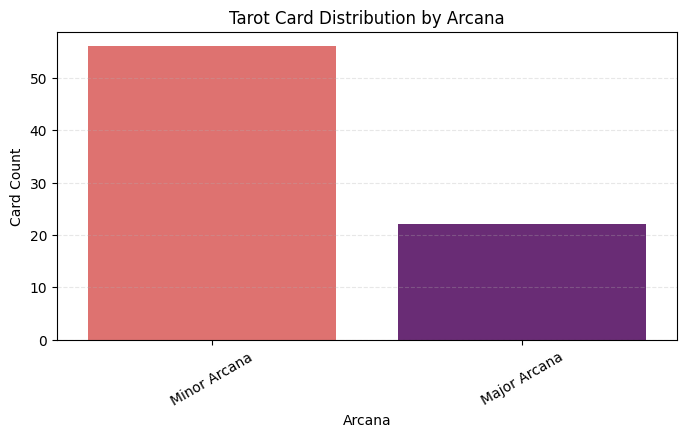

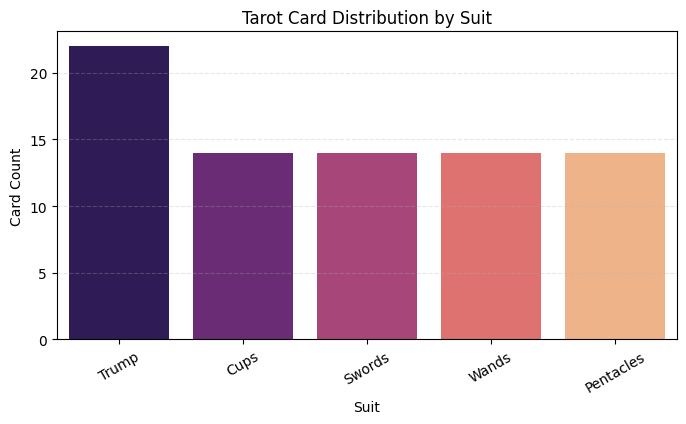

In [12]:
# Step 3: Analyze Card Distribution (Arcana vs. Suits)

import matplotlib.pyplot as plt
import seaborn as sns

# Look for categorical columns like 'suit' or 'type'
cat_cols = [col for col in df_tarot.columns if col.lower() in ['suit', 'type', 'arcana', 'element']]

if cat_cols:
    for col in cat_cols:
        plt.figure(figsize=(8, 4))
        # Handle any missing values safely (like Major Arcana having no suit)
        plot_data = df_tarot[col].fillna('Major Arcana')

        # FIXED: Added hue=plot_data and legend=False to remove the warning message cleanly
        sns.countplot(
            x=plot_data,
            order=plot_data.value_counts().index,
            hue=plot_data,
            palette='magma',
            legend=False
        )

        plt.title(f'Tarot Card Distribution by {col.capitalize()}')
        plt.xlabel(col.capitalize())
        plt.ylabel('Card Count')
        plt.xticks(rotation=30)
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.show()
else:
    print("No categorical columns like 'suit' or 'type' found.")

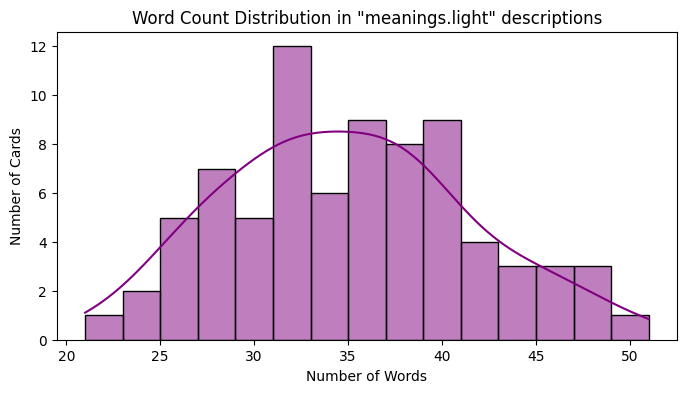

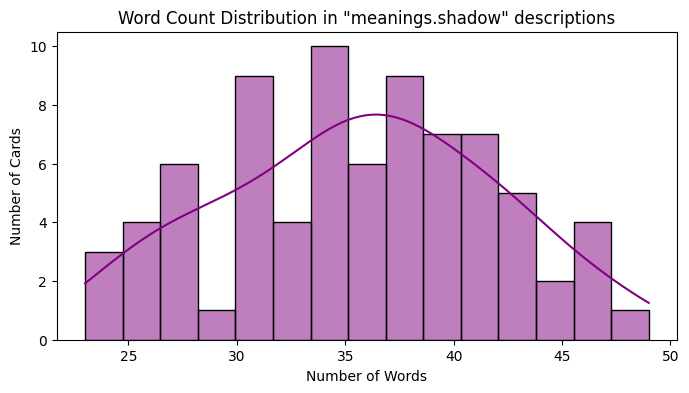

In [8]:
# Step 4: Text Feature Mining (Length of Meanings)

# Detect columns containing card text descriptions
text_cols = [col for col in df_tarot.columns if col.lower() in ['desc', 'meaning_up', 'meaning_rev', 'meanings.light', 'meanings.shadow']]

for col in text_cols:
    length_col_name = f'{col}_word_count'
    # Calculate word count for each individual text field
    df_tarot[length_col_name] = df_tarot[col].astype(str).apply(lambda x: len(x.split()))

    # Plot text distribution profile
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df_tarot, x=length_col_name, kde=True, color='purple', bins=15)
    plt.title(f'Word Count Distribution in "{col}" descriptions')
    plt.xlabel('Number of Words')
    plt.ylabel('Number of Cards')
    plt.show()

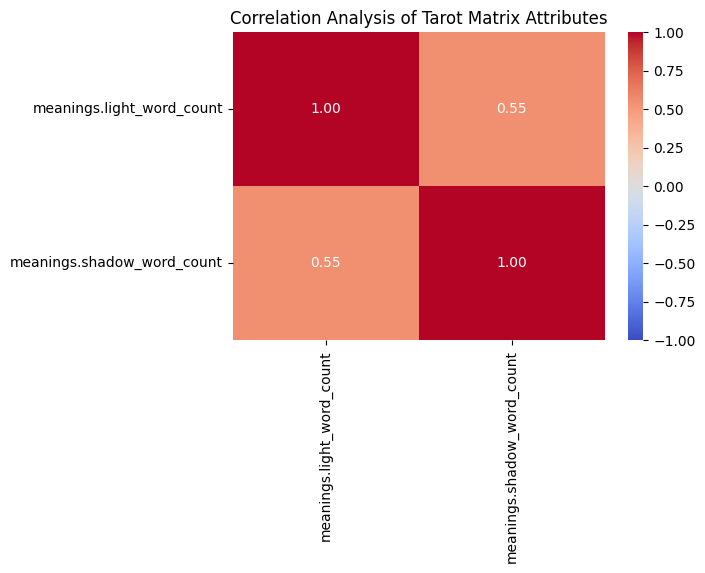

In [7]:
# Step 5: Final Attribute Preview / Matrix Check

numeric_cols = df_tarot.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 1:
    plt.figure(figsize=(6, 4))
    sns.heatmap(df_tarot[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title('Correlation Analysis of Tarot Matrix Attributes')
    plt.show()
else:
    print("Data Preview Profile (Top 3 Cards):")
    display(df_tarot.head(3))